In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt




In [18]:
#downloads the dataset of handwritten numbers from sklearn 
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()

picture = digits.images
correct = digits.target

#flattening pictures into 1d to make it simpler
good_pictures = picture.reshape(picture.shape[0],-1)

#splitting the dataset into test and train

picture_train, picture_test, correct_train, correct_test = train_test_split(good_pictures, correct, test_size = 0.2, random_state=42)


In [47]:
#convert numpy array to pytorch tensors

x_train = torch.from_numpy(picture_train).float()
x_test = torch.from_numpy(picture_test).float()
y_train = torch.from_numpy(correct_train).long()
y_test = torch.from_numpy(correct_test).long()


print(x_train[0].dtype)

torch.float32


In [48]:
#create dataloader and dataset
from torch.utils.data import Dataset, DataLoader

#the dataset
class data(Dataset):
    def __init__ (self, x, y): 
        self.x = x
        self.y = y

    def __len__(self): #special "dunder method", when you call len(data) later, it automatically uses this function. dont use data.len() thanks to dunder
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx] #also special, no need to specify method later, just dataset[the index

#wrapping the dataset in dataloader
training_dataset = data(x_train, y_train)
testing_dataset = data(x_test, y_test)
training_data = DataLoader(training_dataset, batch_size = 32, shuffle=True)
testing_data = DataLoader(testing_dataset, batch_size = 32, shuffle = False) #the __getitem__ and __len__ functions are used by the dataloader internally so it knows how to grab items, batch size, etc. They are needed for every dataset 


In [49]:
#the neural network
import torch.nn as nn
class numbers(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1=nn.Linear(64, 128)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(128,10)
    def forward(self, x):
        x = self.linear1(x)
        x=self.relu(x)
        x=self.linear2(x)
        return  x

In [44]:
for hej, hejsan in training_data:
    print(hej.dtype)

torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64
torch.float64


In [ ]:
import torch.optim as optim

#training loop
epochs = 100
model = numbers()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

loss_over_time = []

for epoch in range(epochs):
    total_loss_per_epoch = 0
    batch = 0
    for x,y in training_data: #takes one batch at a time (32 samples), no additional for loop is needed due to Pytorch's inbuild functions? 
        #1. forward pass
        output = model(x)
        #2. calculate loss
        loss = loss_function(output, y) #this calculates the avarege loss for one batch
        #3. Optimizer zero grad
        optimizer.zero_grad()
        #4. loss backwards
        loss.backward()
        #5. optimizer step
        optimizer.step()

        total_loss_per_epoch += loss.item() #item() converts a python tensor with one number to a regular python number
        batch += 1
    loss_over_time.append(total_loss_per_epoch/batch)

tensor(4.3389, grad_fn=<NllLossBackward0>)
tensor(3.1553, grad_fn=<NllLossBackward0>)
tensor(3.2198, grad_fn=<NllLossBackward0>)
tensor(2.6965, grad_fn=<NllLossBackward0>)
tensor(3.3392, grad_fn=<NllLossBackward0>)
tensor(1.9853, grad_fn=<NllLossBackward0>)
tensor(0.9375, grad_fn=<NllLossBackward0>)
tensor(0.9421, grad_fn=<NllLossBackward0>)
tensor(1.2686, grad_fn=<NllLossBackward0>)
tensor(1.1705, grad_fn=<NllLossBackward0>)
tensor(0.8760, grad_fn=<NllLossBackward0>)
tensor(0.8403, grad_fn=<NllLossBackward0>)
tensor(0.7349, grad_fn=<NllLossBackward0>)
tensor(0.4819, grad_fn=<NllLossBackward0>)
tensor(0.4958, grad_fn=<NllLossBackward0>)
tensor(0.6032, grad_fn=<NllLossBackward0>)
tensor(0.8619, grad_fn=<NllLossBackward0>)
tensor(0.6454, grad_fn=<NllLossBackward0>)
tensor(0.4672, grad_fn=<NllLossBackward0>)
tensor(0.3496, grad_fn=<NllLossBackward0>)
tensor(0.2343, grad_fn=<NllLossBackward0>)
tensor(0.3230, grad_fn=<NllLossBackward0>)
tensor(0.3812, grad_fn=<NllLossBackward0>)
tensor(0.30

In [51]:
#evaluating the model
model.eval()

with torch.no_grad():
    total_correct = 0
    total_test_samples = 0
    for xtest, ytest in testing_data:
        predictions = model(xtest)
        testloss = loss_function(predictions, ytest)

        predicted = torch.max(predictions,1)#go find the most likely number
        #the model processes 32 pictures at once, and each of them gets a 1 dimension tensor. 
        #(predictions, 1) is needed to take the highest value(most likely number) for all 32 pictures in the batch

        correct_per_batch = (predicted[1]==ytest).sum().item()
        total_correct += correct_per_batch
        total_test_samples += ytest.size(0)


    accuracy = total_correct/total_test_samples


print(accuracy)

0.9833333333333333


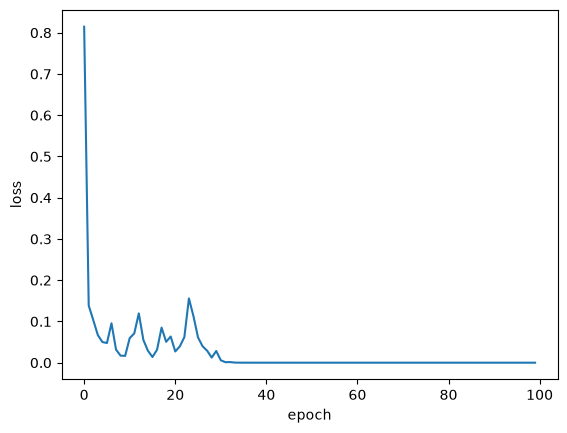

In [57]:
#plotting loss
import matplotlib.pyplot as plt

plt.plot(loss_over_time)
plt.xlabel ("epoch") 
plt.ylabel ("loss")
plt.show()